In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


<div style="padding: 25px; border: 3px solid #6c5ce7; background-color: #f9f8ff; border-radius: 12px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
<h1 style="color: #6c5ce7; text-align: center; margin-top: 0; font-size: 2.2em;">🩺 Santé du Sommeil & Mode de Vie</h1>
<hr style="border: 0; height: 2px; background-image: linear-gradient(to right, rgba(0, 0, 0, 0), #6c5ce7, rgba(0, 0, 0, 0)); margin-bottom: 20px;">

<p style="font-size: 18px; color: #2d3436; line-height: 1.6; text-align: justify;">
Ce projet s'intéresse à l'analyse approfondie des facteurs biologiques et comportementaux (Niveau de stress, Âge, Activité physique, Profession) qui influencent directement la <b>durée et la qualité du sommeil</b>. 
</p>

<p style="font-size: 18px; color: #2d3436; line-height: 1.6; text-align: justify;">
Après une phase rigoureuse de nettoyage et d'exploration des données (EDA), l'objectif principal est de concevoir et de comparer plusieurs <b>modèles de Machine Learning (Régression)</b> afin de prédire avec précision le comportement du sommeil.
</p>

<div style="margin-top: 25px; padding: 15px; background-color: #ffffff; border-left: 5px solid #6c5ce7; border-radius: 4px;">
<p style="margin: 5px 0; font-size: 16px; color: #2d3436;"><b>🎯 Travail Réalisé :</b> Nettoyage Avancé, Analyse Exploratoire (EDA), Visualisation & Modélisation Prédictive (Régression Multi-modèles).</p>
<p style="margin: 5px 0; font-size: 16px; color: #2d3436;"><b>👩‍💻 Réalisé par :</b> BAKALI TAHIRI Noha et BOUASSAB Noaman </p>
</div>
</div>

In [2]:
df_data = pd.read_csv(r"C:\Users\Noha\OneDrive\Desktop\AI101\Machine Learning\ML\Projet_Regression_Collect\Sleep_health_and_lifestyle_dataset-dirty.csv", sep = ';')
df_data


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Sleep Disorder
0,1.0,Male,NaN,Software Engineer,NaN,6.0,NaN,NaN,NaN
1,20.0,NaN,NaN,Doctor,6.2,-6.0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,-6.2,NaN,60.0,8.0,NaN
3,4.0,NaN,-28.0,NaN,NaN,NaN,NaN,NaN,Sleep Apnea
4,NaN,MALE,28.0,NaN,5.9,4.0,30.0,8.0,Seep Apnea
...,...,...,...,...,...,...,...,...,...
369,370.0,NaN,59.0,Nurse,8.1,NaN,NaN,3.0,NaN
370,371.0,Female,NaN,NaN,8.0,9.0,-75.0,3.0,NaN
371,-372.0,Femle,59.0,Nurs,810.0,NaN,NaN,3.0,SLEEP APNEA
372,37300.0,Female,NaN,NaN,NaN,9.0,75.0,3.0,Sleep Apnea


 ## EDA (Exploraty Data Analysis) + Data Cleaning

In [3]:
df = df_data.copy()


In [4]:
df.describe()


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level
count,222.000000,209.000000,235.000000,210.000000,210.000000,228.000000
mean,2107.864865,442.732057,60.084681,667.414286,71.066667,6.364035
std,7412.071721,1303.522530,194.130721,5838.171253,138.796934,12.706581
min,-33400.000000,-59.000000,-8.500000,-800.000000,-90.000000,-60.000000
25%,77.500000,31.000000,6.100000,6.000000,30.000000,3.000000
50%,206.500000,39.000000,7.100000,8.000000,57.500000,5.000000
75%,331.750000,50.000000,7.800000,9.000000,75.000000,7.000000
max,37300.000000,5400.000000,850.000000,60000.000000,900.000000,80.000000


In [5]:
df.shape


(374, 9)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                222 non-null    float64
 1   Gender                   221 non-null    object 
 2   Age                      209 non-null    float64
 3   Occupation               235 non-null    object 
 4   Sleep Duration           235 non-null    float64
 5   Quality of Sleep         210 non-null    float64
 6   Physical Activity Level  210 non-null    float64
 7   Stress Level             228 non-null    float64
 8   Sleep Disorder           101 non-null    object 
dtypes: float64(6), object(3)
memory usage: 26.4+ KB


In [7]:
df.columns


Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'Sleep Disorder'],
      dtype='object')

In [8]:
df = df.reset_index(drop=True) 
df['Person ID'] = df.index +1


In [9]:
df


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Sleep Disorder
0,1,Male,NaN,Software Engineer,NaN,6.0,NaN,NaN,NaN
1,2,NaN,NaN,Doctor,6.2,-6.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,-6.2,NaN,60.0,8.0,NaN
3,4,NaN,-28.0,NaN,NaN,NaN,NaN,NaN,Sleep Apnea
4,5,MALE,28.0,NaN,5.9,4.0,30.0,8.0,Seep Apnea
...,...,...,...,...,...,...,...,...,...
369,370,NaN,59.0,Nurse,8.1,NaN,NaN,3.0,NaN
370,371,Female,NaN,NaN,8.0,9.0,-75.0,3.0,NaN
371,372,Femle,59.0,Nurs,810.0,NaN,NaN,3.0,SLEEP APNEA
372,373,Female,NaN,NaN,NaN,9.0,75.0,3.0,Sleep Apnea


In [10]:
df['Gender'].unique()


array(['Male', nan, 'MALE', 'male', 'Mal', 'ale', 'emale', 'Fmale', 'Mle',
       'Female', 'Femae', 'female', 'Femle', 'FEMALE', 'Femal', 'Feale'],
      dtype=object)

In [11]:
df['Gender'] = df['Gender'].astype(str).str[0].str.upper().map({'M': 'Male', 'F': 'Female'})


In [12]:
df


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Sleep Disorder
0,1,Male,NaN,Software Engineer,NaN,6.0,NaN,NaN,NaN
1,2,NaN,NaN,Doctor,6.2,-6.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,-6.2,NaN,60.0,8.0,NaN
3,4,NaN,-28.0,NaN,NaN,NaN,NaN,NaN,Sleep Apnea
4,5,Male,28.0,NaN,5.9,4.0,30.0,8.0,Seep Apnea
...,...,...,...,...,...,...,...,...,...
369,370,NaN,59.0,Nurse,8.1,NaN,NaN,3.0,NaN
370,371,Female,NaN,NaN,8.0,9.0,-75.0,3.0,NaN
371,372,Female,59.0,Nurs,810.0,NaN,NaN,3.0,SLEEP APNEA
372,373,Female,NaN,NaN,NaN,9.0,75.0,3.0,Sleep Apnea


In [13]:
df['Gender'].value_counts()


Gender
Male      123
Female     89
Name: count, dtype: int64

In [14]:
df


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Sleep Disorder
0,1,Male,NaN,Software Engineer,NaN,6.0,NaN,NaN,NaN
1,2,NaN,NaN,Doctor,6.2,-6.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,-6.2,NaN,60.0,8.0,NaN
3,4,NaN,-28.0,NaN,NaN,NaN,NaN,NaN,Sleep Apnea
4,5,Male,28.0,NaN,5.9,4.0,30.0,8.0,Seep Apnea
...,...,...,...,...,...,...,...,...,...
369,370,NaN,59.0,Nurse,8.1,NaN,NaN,3.0,NaN
370,371,Female,NaN,NaN,8.0,9.0,-75.0,3.0,NaN
371,372,Female,59.0,Nurs,810.0,NaN,NaN,3.0,SLEEP APNEA
372,373,Female,NaN,NaN,NaN,9.0,75.0,3.0,Sleep Apnea


In [15]:
df['Gender'].fillna('Male',inplace = True)


C:\Users\Noha\AppData\Local\Temp\ipykernel_3860\2312204653.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna('Male',inplace = True)


In [16]:
df


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Sleep Disorder
0,1,Male,NaN,Software Engineer,NaN,6.0,NaN,NaN,NaN
1,2,Male,NaN,Doctor,6.2,-6.0,NaN,NaN,NaN
2,3,Male,NaN,NaN,-6.2,NaN,60.0,8.0,NaN
3,4,Male,-28.0,NaN,NaN,NaN,NaN,NaN,Sleep Apnea
4,5,Male,28.0,NaN,5.9,4.0,30.0,8.0,Seep Apnea
...,...,...,...,...,...,...,...,...,...
369,370,Male,59.0,Nurse,8.1,NaN,NaN,3.0,NaN
370,371,Female,NaN,NaN,8.0,9.0,-75.0,3.0,NaN
371,372,Female,59.0,Nurs,810.0,NaN,NaN,3.0,SLEEP APNEA
372,373,Female,NaN,NaN,NaN,9.0,75.0,3.0,Sleep Apnea


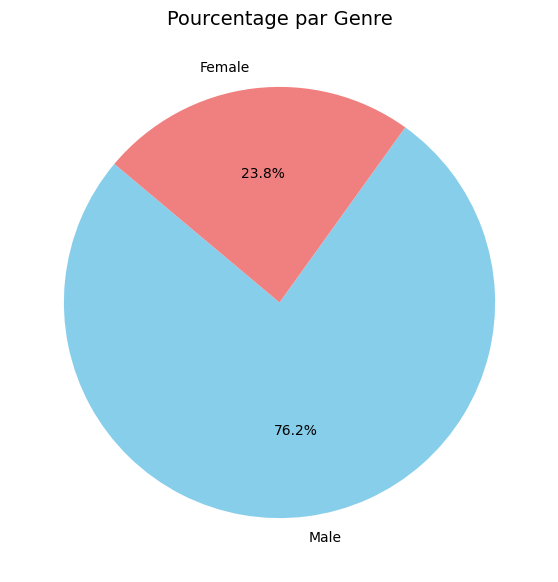

In [17]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
        colors=['skyblue', 'lightcoral'], startangle=140)

plt.title("Pourcentage par Genre", fontsize=14)

plt.show()


 <div style="padding: 15px; border-left: 10px solid #2c3e50; background-color: #f4f6f7; border-radius: 5px; font-family: sans-serif;">

 <h3 style="color: #2c3e50; margin: 0;">📊 Observation de la Répartition</h3>

 <p style="color: #34495e; font-size: 16px; margin-top: 10px;">

 D'après le graphique, nous constatons une <b>prédominance masculine</b> dans les données traitées :

 </p>

 <ul style="line-height: 1.6; color: #2c3e50;">

 <li><b>Hommes (Male) :</b> Représentent la grande majorité avec <b>76.2%</b>.</li>

 <li><b>Femmes (Female) :</b> Représentent <b>23.8%</b> de l'échantillon.</li>

 </ul>

 <p style="font-size: 15px; color: #7f8c8d; margin-bottom: 0;">

 </p>

 </div>

In [18]:
df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Sleep Disorder
0,1,Male,NaN,Software Engineer,NaN,6.0,NaN,NaN,NaN
1,2,Male,NaN,Doctor,6.2,-6.0,NaN,NaN,NaN
2,3,Male,NaN,NaN,-6.2,NaN,60.0,8.0,NaN
3,4,Male,-28.0,NaN,NaN,NaN,NaN,NaN,Sleep Apnea
4,5,Male,28.0,NaN,5.9,4.0,30.0,8.0,Seep Apnea


In [19]:
df['Age'].unique()


array([  nan,  -28.,   28.,   29.,  -29.,  -30.,   30.,   31., 3100.,
         32.,  -32.,   33.,   34.,   35.,  -35.,   36.,  -36., 3700.,
         37.,  -37.,   38., 3800.,  -38.,   39., 3900.,   40., 4000.,
       4100.,   41.,  -42.,   42.,  -43., 4300.,   43.,   44.,  -44.,
       4400.,  -45., 4500.,   45.,  -48.,  -49.,   49., 4900.,   50.,
        -50., 5000.,   51.,   52., 5200.,   53.,  -53., 5300.,   54.,
       5400.,   55.,  -56.,   57.,  -57.,   58.,  -58.,   59.,  -59.])

In [20]:
df['Age'] = df['Age'].abs()


In [21]:
df['Age'].unique()


array([  nan,   28.,   29.,   30.,   31., 3100.,   32.,   33.,   34.,
         35.,   36., 3700.,   37.,   38., 3800.,   39., 3900.,   40.,
       4000., 4100.,   41.,   42.,   43., 4300.,   44., 4400.,   45.,
       4500.,   48.,   49., 4900.,   50., 5000.,   51.,   52., 5200.,
         53., 5300.,   54., 5400.,   55.,   56.,   57.,   58.,   59.])

In [22]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')


In [23]:
def corriger_age(age):
    if age > 120:
        return age / 100
    else:
        return age

df['Age'] = df['Age'].apply(corriger_age)


In [24]:
df['Age'].unique()


array([nan, 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
       40., 41., 42., 43., 44., 45., 48., 49., 50., 51., 52., 53., 54.,
       55., 56., 57., 58., 59.])

In [25]:
df['Age'].isnull().sum()


np.int64(165)

In [26]:
df.describe()


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level
count,374.000000,209.000000,235.000000,210.000000,210.000000,228.000000
mean,187.500000,41.923445,60.084681,667.414286,71.066667,6.364035
std,108.108742,8.791598,194.130721,5838.171253,138.796934,12.706581
min,1.000000,28.000000,-8.500000,-800.000000,-90.000000,-60.000000
25%,94.250000,35.000000,6.100000,6.000000,30.000000,3.000000
50%,187.500000,41.000000,7.100000,8.000000,57.500000,5.000000
75%,280.750000,49.000000,7.800000,9.000000,75.000000,7.000000
max,374.000000,59.000000,850.000000,60000.000000,900.000000,80.000000


In [27]:
df['Age'] = df['Age'].fillna(df['Age'].mean())


In [28]:
df['Age'].isnull().sum()


np.int64(0)

In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    float64
 3   Occupation               235 non-null    object 
 4   Sleep Duration           235 non-null    float64
 5   Quality of Sleep         210 non-null    float64
 6   Physical Activity Level  210 non-null    float64
 7   Stress Level             228 non-null    float64
 8   Sleep Disorder           101 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 26.4+ KB


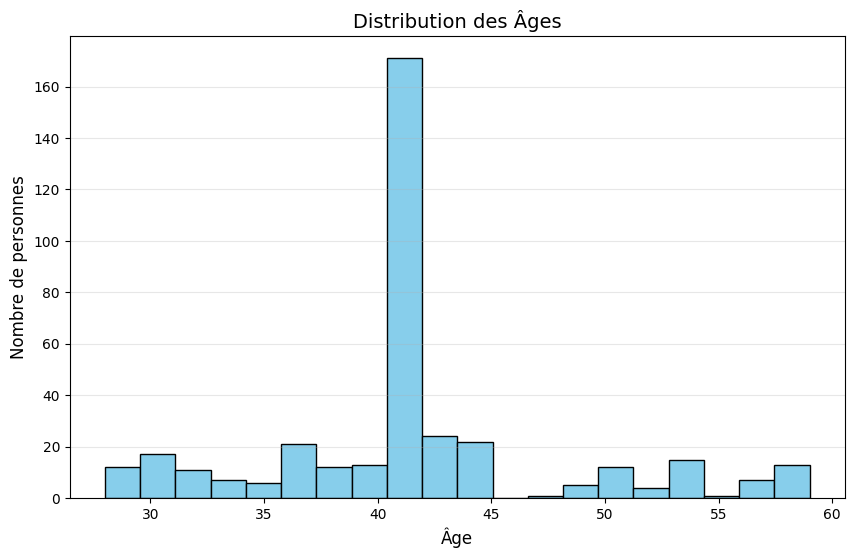

In [30]:

plt.figure(figsize=(10, 6))

plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')


plt.title("Distribution des Âges", fontsize=14)
plt.xlabel("Âge", fontsize=12)
plt.ylabel("Nombre de personnes", fontsize=12)

plt.grid(axis='y', alpha=0.3) 
plt.show()



 <div style="padding: 15px; border-left: 10px solid #5dade2; background-color: #ebf5fb; border-radius: 5px;">

 <h2 style="color: #2e86c1; margin: 0; font-family: sans-serif;">Distribution des Âges</h2>

 <hr style="border: 1px solid #aed6f1;">

 <p style="color: #2d3436; font-size: 16px;">Analyse de la pyramide des âges de l'échantillon :</p>

 <ul style="line-height: 1.8; color: #2d3436;">

 <li><b style="color: #e67e22;">Point Majeur :</b> Une concentration massive de données autour de <b>42-43 ans</b>.</li>

 <li><b style="color: #2e86c1;">Diversité :</b> Présence de données allant de 25 à 60 ans, mais de façon moins dense.</li>



 </ul>

 <div style="background-color: #aed6f1; padding: 5px 10px; border-radius: 10px; color: #1b4f72; font-size: 15px;">

 <i><b>Note :</b> La forte présence de la quarantaine suggère que les conclusions sur le sommeil seront particulièrement précises pour cette tranche d'âge.</i>

 </div>

 </div>

In [31]:
df['Age'].isnull().sum()


np.int64(0)

In [32]:
df['Age'] = df['Age'].round(2)


In [33]:
df['Age'].value_counts()


Age
41.92    165
43.00     18
44.00     14
37.00     13
38.00     12
32.00     11
31.00     10
53.00     10
50.00     10
29.00      9
59.00      9
39.00      9
36.00      8
45.00      8
30.00      7
33.00      6
41.00      6
42.00      6
35.00      6
57.00      6
49.00      5
54.00      5
40.00      4
58.00      4
52.00      4
28.00      3
51.00      2
34.00      1
48.00      1
55.00      1
56.00      1
Name: count, dtype: int64

In [34]:
df


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Sleep Disorder
0,1,Male,41.92,Software Engineer,NaN,6.0,NaN,NaN,NaN
1,2,Male,41.92,Doctor,6.2,-6.0,NaN,NaN,NaN
2,3,Male,41.92,NaN,-6.2,NaN,60.0,8.0,NaN
3,4,Male,28.00,NaN,NaN,NaN,NaN,NaN,Sleep Apnea
4,5,Male,28.00,NaN,5.9,4.0,30.0,8.0,Seep Apnea
...,...,...,...,...,...,...,...,...,...
369,370,Male,59.00,Nurse,8.1,NaN,NaN,3.0,NaN
370,371,Female,41.92,NaN,8.0,9.0,-75.0,3.0,NaN
371,372,Female,59.00,Nurs,810.0,NaN,NaN,3.0,SLEEP APNEA
372,373,Female,41.92,NaN,NaN,9.0,75.0,3.0,Sleep Apnea


In [35]:
df['Occupation'].unique()


array(['Software Engineer', 'Doctor', nan, 'TEACHER', 'doctor', 'Nurse',
       'DOCTOR', 'Dotor', 'octor', 'Scientist', 'Teacher',
       'SOFTWARE ENGINEER', 'Engineer', 'ENGINEER', 'LAWYER',
       'accountant', 'Accountant', 'teacher', 'ACCOUNTANT', 'Lawyer',
       'Lwyer', 'lawyer', 'Lawer', 'Salesperson', 'SALESPERSON',
       'Saleperson', 'engineer', 'salesperson', 'Manager', 'Nuse',
       'nurse', 'Engiee', 'Enginee', 'Nurs', 'NURSE'], dtype=object)

In [36]:
def clean_occupation(x):
    x = str(x).strip()
    
    if x in ['nurse', 'Nuse', 'NURSE', 'Nurs', 'Nurse']:
        return 'Nurse'
    
    elif x in ['Lwyer', 'Lawer', 'lawyer', 'LAWYER', 'Lawyer']:
        return 'Lawyer'
    
    elif x in ['DOCTOR', 'doctor', 'Dotor', 'octor', 'Doctor']:
        return 'Doctor'
    
    elif x in ['engineer', 'ENGINEER', 'Enginee', 'Engiee', 'Engineer']:
        return 'Engineer'
    
    elif x in ['ACCOUNTANT','accountant']:
        return 'Accountant'
    
    elif x in ['SOFTWARE ENGINEER']:
        return 'Software Engineer'
    
    elif x in ['teacher','TEACHER']:
        return 'Teacher'
    
    elif x in ['salesperson','Saleperson','SALESPERSON']:
        return 'Salesperson'
    
    return x

df['Occupation'] = df['Occupation'].apply(clean_occupation)

print(df['Occupation'].unique())


['Software Engineer' 'Doctor' 'nan' 'Teacher' 'Nurse' 'Scientist'
 'Engineer' 'Lawyer' 'Accountant' 'Salesperson' 'Manager']


In [37]:

df = df.replace(['nan', 'NaN', 'NAN', 'n/a'], np.nan)


In [38]:
df['Occupation'].value_counts()


Occupation
Nurse                54
Doctor               45
Engineer             34
Lawyer               28
Teacher              24
Accountant           23
Salesperson          20
Scientist             4
Software Engineer     2
Manager               1
Name: count, dtype: int64

In [39]:
df['Occupation'].isnull().sum()


np.int64(139)

In [40]:
df['Occupation'] = df['Occupation'].fillna('Nurse')


In [41]:
df['Occupation'].value_counts()


Occupation
Nurse                193
Doctor                45
Engineer              34
Lawyer                28
Teacher               24
Accountant            23
Salesperson           20
Scientist              4
Software Engineer      2
Manager                1
Name: count, dtype: int64

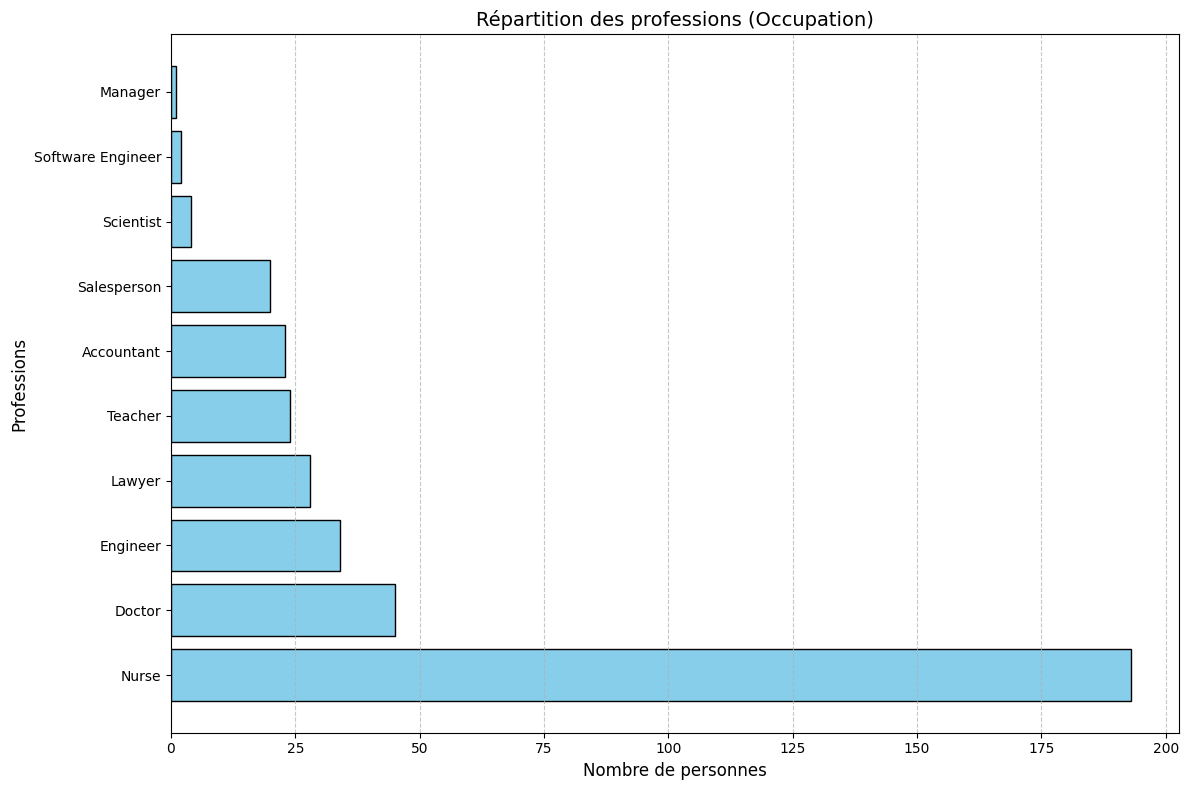

In [42]:
counts = df['Occupation'].value_counts()

plt.figure(figsize=(12, 8))
plt.barh(counts.index, counts.values, color='skyblue', edgecolor='black')

plt.title("Répartition des professions (Occupation)", fontsize=14)
plt.xlabel("Nombre de personnes", fontsize=12)
plt.ylabel("Professions", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout() 
plt.show()


 <div style="padding: 15px; border-left: 10px solid #2980b9; background-color: #f0f7fb; border-radius: 5px;">

 <h2 style="color: #2471a3; margin: 0; font-family: sans-serif;">Répartition par Profession</h2>

 <hr style="border: 1px solid #d4e6f1;">

 <p style="color: #2d3436; font-size: 16px;"><b>Observation :</b> La catégorie <b>Nurse</b> est prédominante (> 175 personnes), suivie par les Docteurs.</p>

 </div>

In [43]:
df.describe()


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level
count,374.000000,374.000000,235.000000,210.000000,210.000000,228.000000
mean,187.500000,41.921925,60.084681,667.414286,71.066667,6.364035
std,108.108742,6.565156,194.130721,5838.171253,138.796934,12.706581
min,1.000000,28.000000,-8.500000,-800.000000,-90.000000,-60.000000
25%,94.250000,39.000000,6.100000,6.000000,30.000000,3.000000
50%,187.500000,41.920000,7.100000,8.000000,57.500000,5.000000
75%,280.750000,43.000000,7.800000,9.000000,75.000000,7.000000
max,374.000000,59.000000,850.000000,60000.000000,900.000000,80.000000


In [44]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    float64
 3   Occupation               374 non-null    object 
 4   Sleep Duration           235 non-null    float64
 5   Quality of Sleep         210 non-null    float64
 6   Physical Activity Level  210 non-null    float64
 7   Stress Level             228 non-null    float64
 8   Sleep Disorder           101 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 26.4+ KB


In [45]:
df['Sleep Duration'] = df['Sleep Duration'].abs()


In [46]:
def corriger_sleep_duration(sleep):
    if sleep > 24:
        return sleep / 100
    else:
        return sleep

df['Sleep Duration'] = df['Sleep Duration'].apply(corriger_sleep_duration)


In [47]:
df['Sleep Duration'].dtype


dtype('float64')

In [48]:
df['Sleep Duration'].unique()


array([nan, 6.2, 5.9, 6.3, 7.8, 6.1, 6. , 6.5, 7.6, 7.7, 7.9, 6.4, 7.5,
       7.2, 5.8, 6.7, 7.3, 7.4, 7.1, 6.6, 8. , 6.8, 8.1, 8.3, 8.5, 8.4,
       8.2])

In [49]:
df['Sleep Duration'].isnull().sum()


np.int64(139)

In [50]:
df['Sleep Duration'].mean()


np.float64(7.118723404255319)

In [51]:
df['Sleep Duration'] = df['Sleep Duration'].fillna(df['Sleep Duration'].mean())


In [52]:
df['Sleep Duration'] = df['Sleep Duration'].round(2)


In [53]:
df['Sleep Duration'].value_counts()


Sleep Duration
7.12    139
7.20     24
6.00     18
6.10     16
7.70     16
7.80     16
6.50     15
6.60     15
7.10     13
7.30     11
6.30     10
8.00      9
8.10      9
8.50      8
7.60      8
8.20      8
6.20      7
8.40      6
6.40      5
6.80      3
7.40      3
7.50      3
6.70      3
8.30      3
5.90      2
7.90      2
5.80      2
Name: count, dtype: int64

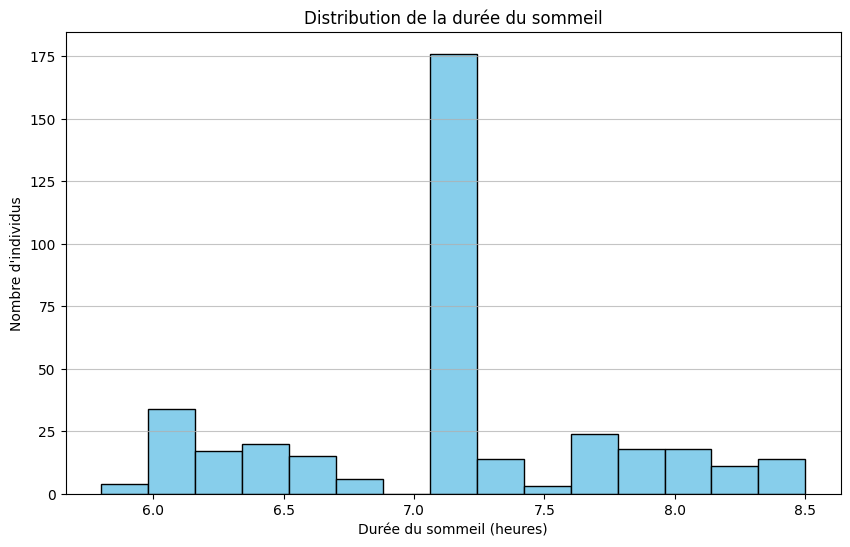

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df['Sleep Duration'], bins=15, color='skyblue', edgecolor='black')

plt.title("Distribution de la durée du sommeil")
plt.xlabel("Durée du sommeil (heures)")
plt.ylabel("Nombre d'individus")

plt.grid(axis='y', alpha=0.75)

plt.show()


 <div style="padding: 15px; border-left: 10px solid #27ae60; background-color: #f1f9f5; border-radius: 5px;">

 <h2 style="color: #1e8449; margin: 0; font-family: sans-serif;">Distribution de la Durée du Sommeil</h2>

 <hr style="border: 1px solid #abebc6;">

 <p style="color: #2d3436; font-size: 16px;"><b>Analyse des heures de repos :</b></p>

 <ul style="line-height: 1.8; color: #2d3436;">

 <li><b style="color: #27ae60;">Valeur dominante :</b> La grande majorité des individus dorment environ <b>7.2 heures</b>.</li>

 <li><b style="color: #2980b9;">Variabilité :</b> La durée varie entre 5.8 et 8.5 heures, mais avec des effectifs plus réduits aux extrémités.</li>

 </ul>

 <div style="background-color: #abebc6; padding: 5px 10px; border-radius: 10px; color: #145a32; font-size: 15px;">

 <i><b>Note :</b> Un sommeil de 7.2h est cliniquement considéré comme une durée saine et équilibrée pour un adulte.</i>

 </div>

 </div>

In [55]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    float64
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         210 non-null    float64
 6   Physical Activity Level  210 non-null    float64
 7   Stress Level             228 non-null    float64
 8   Sleep Disorder           101 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 26.4+ KB


In [56]:
df['Quality of Sleep'].isnull().value_counts()


Quality of Sleep
False    210
True     164
Name: count, dtype: int64

In [57]:
df['Quality of Sleep'].nunique()


18

In [58]:
df['Quality of Sleep'].value_counts()


Quality of Sleep
 8.0        48
 6.0        40
 7.0        36
 9.0        34
 600.0      12
 800.0       8
 700.0       6
 5.0         5
 900.0       3
 4.0         3
-9.0         3
-7.0         3
-800.0       3
 60000.0     2
-6.0         1
 500.0       1
-8.0         1
 400.0       1
Name: count, dtype: int64

In [59]:
df['Quality of Sleep'] = df['Quality of Sleep'].abs()


In [60]:
df.loc[df['Quality of Sleep'] > 10, 'Quality of Sleep'] = df['Quality of Sleep'] / 100

while df['Quality of Sleep'].max() > 10:
    df.loc[df['Quality of Sleep'] > 10, 'Quality of Sleep'] = df['Quality of Sleep'] / 10


In [61]:
df['Quality of Sleep'].value_counts()


Quality of Sleep
8.0    60
6.0    55
7.0    45
9.0    40
5.0     6
4.0     4
Name: count, dtype: int64

In [62]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    float64
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         210 non-null    float64
 6   Physical Activity Level  210 non-null    float64
 7   Stress Level             228 non-null    float64
 8   Sleep Disorder           101 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 26.4+ KB


In [63]:
df['Quality of Sleep'] = df['Quality of Sleep'].fillna(df['Quality of Sleep'].mean())


In [64]:
df['Physical Activity Level'].isnull().value_counts()


Physical Activity Level
False    210
True     164
Name: count, dtype: int64

In [65]:
df['Physical Activity Level'].value_counts()


Physical Activity Level
 30.0     35
 45.0     33
 60.0     32
 90.0     31
 75.0     26
-75.0      7
-60.0      6
-90.0      5
 40.0      4
-30.0      3
-45.0      3
 450.0     3
 85.0      2
 35.0      2
 50.0      2
 55.0      2
 900.0     2
 600.0     2
 80.0      2
 750.0     1
 700.0     1
 70.0      1
 42.0      1
 47.0      1
 550.0     1
 65.0      1
-55.0      1
Name: count, dtype: int64

In [66]:
df['Physical Activity Level'] = df['Physical Activity Level'].abs()


In [67]:
df.loc[df['Physical Activity Level'] > 100, 'Physical Activity Level'] = df['Physical Activity Level'] / 10


In [68]:
df['Physical Activity Level'] = df['Physical Activity Level'].fillna(df['Physical Activity Level'].mean())


In [69]:
df['Physical Activity Level'] = df['Physical Activity Level'].round(2)


In [70]:
df['Physical Activity Level'].value_counts()


Physical Activity Level
59.23    164
60.00     40
45.00     39
30.00     38
90.00     38
75.00     34
55.00      4
40.00      4
50.00      2
35.00      2
80.00      2
70.00      2
85.00      2
42.00      1
47.00      1
65.00      1
Name: count, dtype: int64

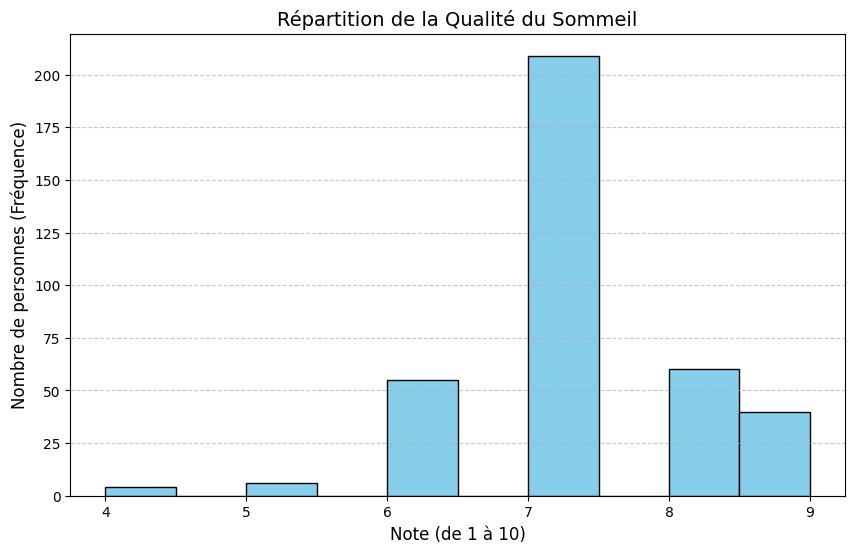

In [71]:

plt.figure(figsize=(10, 6))

plt.hist(df['Quality of Sleep'], bins=10, color='skyblue', edgecolor='black')

plt.title('Répartition de la Qualité du Sommeil', fontsize=14)
plt.xlabel('Note (de 1 à 10)', fontsize=12)
plt.ylabel('Nombre de personnes (Fréquence)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


 <div style="padding: 15px; border-left: 10px solid #1abc9c; background-color: #e8f8f5; border-radius: 5px;">

 <h2 style="color: #16a085; margin: 0; font-family: sans-serif;">Durée et Qualité du Sommeil</h2>

 <hr style="border: 1px solid #a3e4d7;">

 <ul style="color: #2d3436; line-height: 1.6;">

 <li><b>Durée :</b> Un pic massif à <b>7.2 heures</b>.</li>

 <li><b>Qualité :</b> La note de <b>7/10</b> est la plus fréquente.</li>

 </ul>

 <div style="background-color: #a3e4d7; padding: 5px 10px; border-radius: 10px; color: #0e6251; font-size: 15x;">

 <i><b>Note :</b> Globalement, l'échantillon a un sommeil plutôt satisfaisant.</i>

 </div>

 </div>

In [72]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    float64
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    float64
 6   Physical Activity Level  374 non-null    float64
 7   Stress Level             228 non-null    float64
 8   Sleep Disorder           101 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 26.4+ KB


In [73]:
df['Stress Level'].unique()


array([ nan,   8.,   6.,  -8.,   7., -60.,  -6.,   4.,  60.,   3.,  80.,
         5.,  -4.,  -7.,  -5.,  50.,  40.,  70.,  30.,  -3.])

In [74]:
df['Stress Level'] = df['Stress Level'].abs()


In [75]:
df.loc[df['Stress Level'] > 10, 'Stress Level'] = df['Stress Level'] / 10


In [76]:
df ['Stress Level']= df['Stress Level'].fillna(df['Stress Level'].mean())


In [77]:
df['Stress Level'] = df['Stress Level'].round(2)


In [78]:
df['Stress Level'].value_counts()


Stress Level
5.29    146
3.00     47
4.00     45
5.00     39
8.00     38
7.00     31
6.00     28
Name: count, dtype: int64

In [79]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    float64
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    float64
 6   Physical Activity Level  374 non-null    float64
 7   Stress Level             374 non-null    float64
 8   Sleep Disorder           101 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 26.4+ KB


In [80]:
df['Sleep Disorder'].unique()


array([nan, 'Sleep Apnea', 'Seep Apnea', 'Insomnia', 'slee apnea',
       'sleep apnea', 'Insomna', 'Insmnia', 'insomnia', 'INSOMNIA',
       'SEEP APNEA', 'Sleep Anea', 'SLEEP APNEA', 'SleepApnea'],
      dtype=object)

In [81]:
df['Sleep Disorder'] = df['Sleep Disorder'].str.strip().str.lower()

corrections = {
    'insomna': 'Insomnia',
    'insmnia': 'Insomnia',
    'insomnia': 'Insomnia',
    'sleep apnea': 'Sleep Apnea',
    'seep apnea': 'Sleep Apnea',
    'slee apnea': 'Sleep Apnea',
    'sleep anea': 'Sleep Apnea',
    'sleepapnea': 'Sleep Apnea'
}

df['Sleep Disorder'] = df['Sleep Disorder'].replace(corrections)

df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

df['Sleep Disorder'].unique()


array(['None', 'Sleep Apnea', 'Insomnia'], dtype=object)

In [82]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    float64
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    float64
 6   Physical Activity Level  374 non-null    float64
 7   Stress Level             374 non-null    float64
 8   Sleep Disorder           374 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 26.4+ KB


 #### Gestion d'Outliers

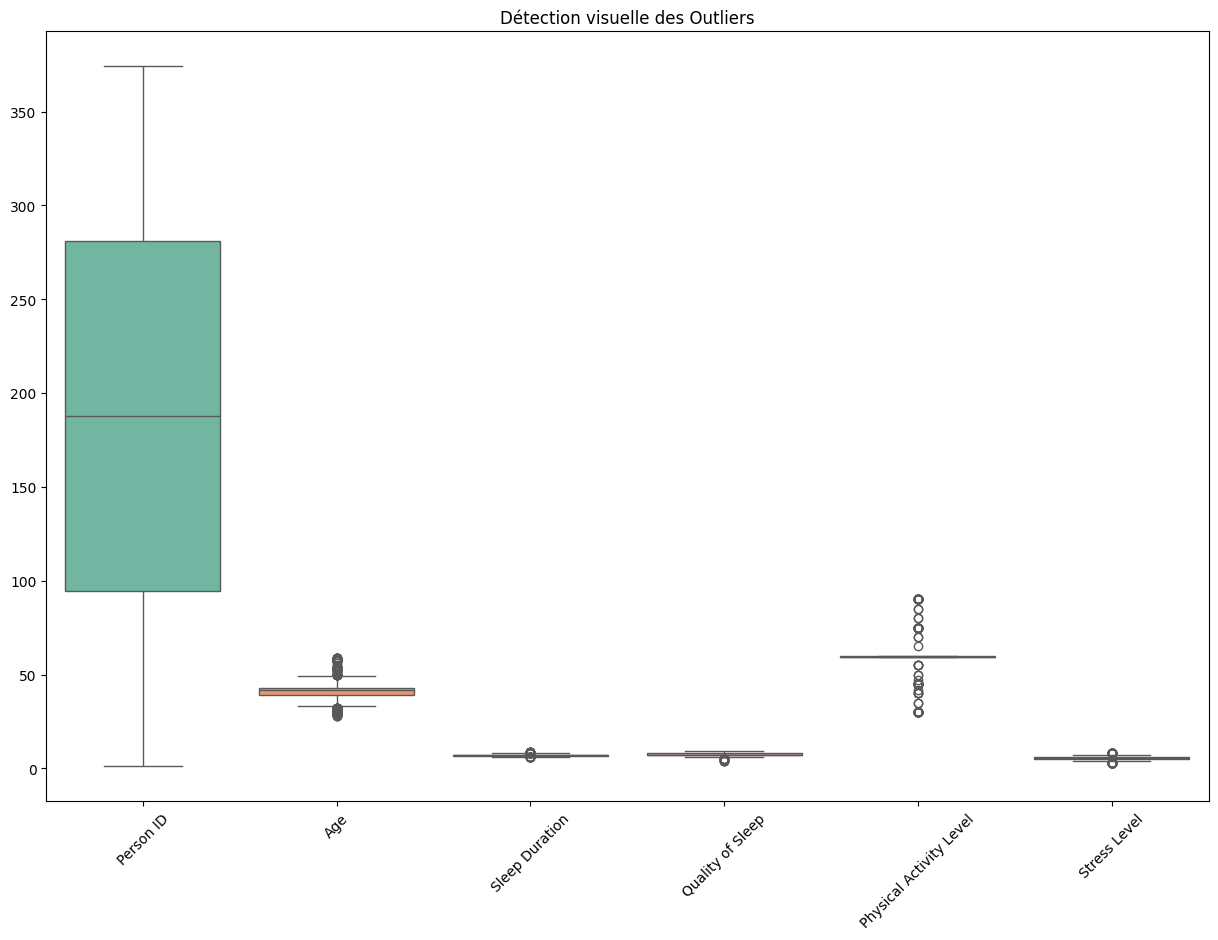

In [83]:
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
sns.boxplot(data=df[numeric_cols], palette="Set2")
plt.xticks(rotation=45)
plt.title("Détection visuelle des Outliers")
plt.show()


 <div style="padding: 15px; border-left: 10px solid #f39c12; background-color: #fffaf0; border-radius: 5px;">

 <h2 style="color: #d35400; margin: 0; font-family: sans-serif;">Analyse Visuelle des Outliers</h2>

 <hr style="border: 1px solid #f9e79f;">

 <p style="color: #2d3436; font-size: 16px;">L'utilisation des <b>Boxplots</b> a permis d'identifier quelques points isolés :</p>

 <ul style="line-height: 1.8; color: #2d3436;">

 <li><b>Age :</b> Quelques individus se situent en dehors de la moyenne centrale (42 ans).</li>

 <li><b>Activité Physique :</b> Des pics d'activité intense sont visibles comme des points isolés.</li>

 <li><b>Décision :</b> Ces valeurs sont conservées car elles représentent des cas réels et non des erreurs de saisie.</li>

 </ul>

 <div style="background-color: #f9e79f; padding: 5px 10px; border-radius: 10px; color: #7e5109; font-size: 15px;">

 <i><b>Note :</b> En Data Science Santé, un point isolé n'est pas toujours une erreur, c'est parfois une exception clinique intéressante.</i>

 </div>

 </div>

 ## Questions de l'analyse

 #### 1-Le stress influence-t-il la durée du sommeil ? (Objectif : Analyser la relation entre le niveau de stress et la durée du sommeil)

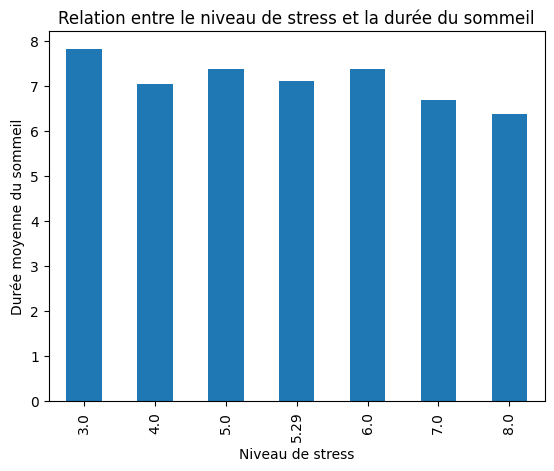

In [84]:
df.groupby('Stress Level')['Sleep Duration'].mean().plot(kind='bar')
plt.title('Relation entre le niveau de stress et la durée du sommeil')
plt.xlabel('Niveau de stress')
plt.ylabel('Durée moyenne du sommeil')
plt.show()


 <div style="padding: 15px; border-left: 10px solid #e74c3c; background-color: #fdf2f2; border-radius: 5px;">

 <h2 style="color: #c0392b; margin: 0; font-family: sans-serif;">📉 Stress vs Durée du Sommeil</h2>

 <hr style="border: 1px solid #fab1a0;">

 <p style="color: #2d3436;"><b>Corrélation :</b> On remarque que les personnes avec un <b>Stress Level de 8.0</b> dorment moins (~6.2h) que celles à bas stress.</p>

 <div style="background-color: #fab1a0; padding: 5px 10px; border-radius: 10px; color: #7b241c; font-size: 15px;">

 <i><b>Conclusion :</b> Le stress est un facteur limitant direct de la quantité de repos.</i>

 </div>

 </div>

 #### 2-L’activité physique améliore-t-elle la qualité du sommeil ? (Objectif : Étudier l’impact de l’activité physique sur la qualité du sommeil.)



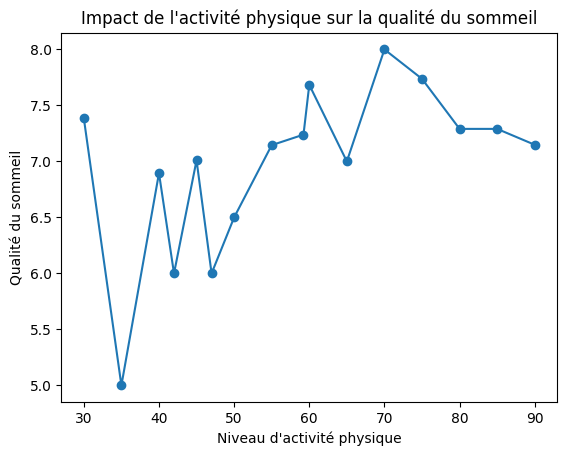

In [85]:
df.groupby('Physical Activity Level')['Quality of Sleep'].mean().plot(kind='line', marker='o')
plt.title("Impact de l'activité physique sur la qualité du sommeil")
plt.xlabel("Niveau d'activité physique")
plt.ylabel("Qualité du sommeil")
plt.show()


 <div style="padding: 15px; border-left: 10px solid #f39c12; background-color: #fef9e7; border-radius: 5px;">

 <h2 style="color: #d35400; margin: 0; font-family: sans-serif;">Niveau d'Activité Physique</h2>

 <hr style="border: 1px solid #f9e79f;">

 <p style="color: #2d3436;"><b>Distribution :</b> Les données sont concentrées sur des niveaux précis (30, 60, 90), suggérant des paliers d'exercice.</p>

 </div>

In [86]:
check_35 = df[(df['Age'] >= 34) & (df['Age'] <= 36)]
check_35[['Age', 'Quality of Sleep', 'Occupation']]


,Age,Quality of Sleep,Occupation
80,34.0,4.000000,Scientist
82,35.0,7.290476,Nurse
86,35.0,8.000000,Nurse
88,35.0,8.000000,Engineer
90,35.0,7.290476,Nurse
91,35.0,8.000000,Nurse
92,35.0,7.290476,Nurse
95,36.0,8.000000,Accountant
96,36.0,8.000000,Nurse
97,36.0,8.000000,Nurse


 <div style="padding: 15px; border-left: 10px solid #1abc9c; background-color: #e8f8f5; border-radius: 5px;">

 <h2 style="color: #16a085; margin: 0; font-family: sans-serif;">Activité Physique vs Qualité du Sommeil</h2>

 <hr style="border: 1px solid #a3e4d7;">

 <p style="color: #2d3436; font-size: 16px;">Étude de l'impact du sport sur le repos nocturne :</p>

 <ul style="line-height: 1.8; color: #2d3436;">

 <li><b style="color: #e67e22;">Sédentarité :</b> Un faible niveau d'activité (< 40) est lié à la plus basse qualité de sommeil.</li>

 <li><b style="color: #16a085;">Zone Optimale :</b> Le score de sommeil atteint son maximum (8.0) pour un niveau d'activité de 70.</li>

 <li><b style="color: #2980b9;">Équilibre :</b> Au-delà de 75, la qualité se stabilise, suggérant qu'une activité modérée à intense est suffisante.</li>

 </ul>

 <div style="background-color: #a3e4d7; padding: 5px 10px; border-radius: 13px; color: #0e6251; font-size: 15px;">

 <i><b>Conseil Santé :</b> Pratiquer une activité physique régulière est l'un des leviers les plus puissants pour améliorer son sommeil.</i>

 </div>

 </div>

 #### 3- Quelles professions sont les plus stressantes ? (Objectif : Identifier les métiers avec le niveau de stress le plus élevé.)

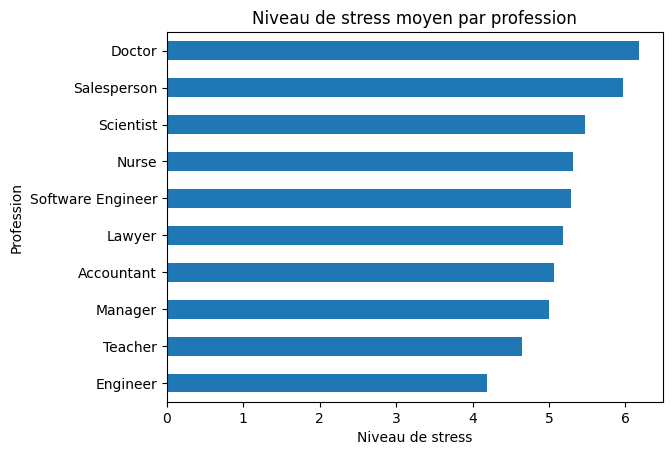

In [87]:
df.groupby('Occupation')['Stress Level'].mean().sort_values().plot(kind='barh')
plt.title('Niveau de stress moyen par profession')
plt.xlabel('Niveau de stress')
plt.ylabel('Profession')
plt.show()


 <div style="padding: 15px; border-left: 10px solid #8e44ad; background-color: #f5eef8; border-radius: 5px;">

 <h2 style="color: #6c3483; margin: 0; font-family: sans-serif;">Niveau de Stress par Profession</h2>

 <hr style="border: 1px solid #d7bde2;">

 <p style="color: #2d3436; font-size: 16px;">Classement des métiers selon l'intensité du stress ressenti :</p>

 <ul style="line-height: 1.8; color: #2d3436;">

 <li><b style="color: #c0392b;">Métiers sous haute pression :</b> Les Docteurs et les Commerciaux (Stress > 6).</li>

 <li><b style="color: #8e44ad;">Secteur Santé (Nurse) :</b> Présente un niveau de stress significatif, se classant dans le top 5.</li>

 <li><b style="color: #27ae60;">Métiers plus calmes :</b> Les Ingénieurs semblent avoir le mode de vie le moins stressant de l'étude.</li>

 </ul>

 <div style="background-color: #d7bde2; padding: 5px 10px; border-radius: 13px; color: #4a235a; font-size: 15px;">

 <i><b>Note :</b> Ce graphique confirme que les professions de santé restent parmi les plus exigeantes émotionnellement.</i>

 </div>

 </div>

 #### 4-Combien de personnes souffrent de chaque type de trouble du sommeil ?

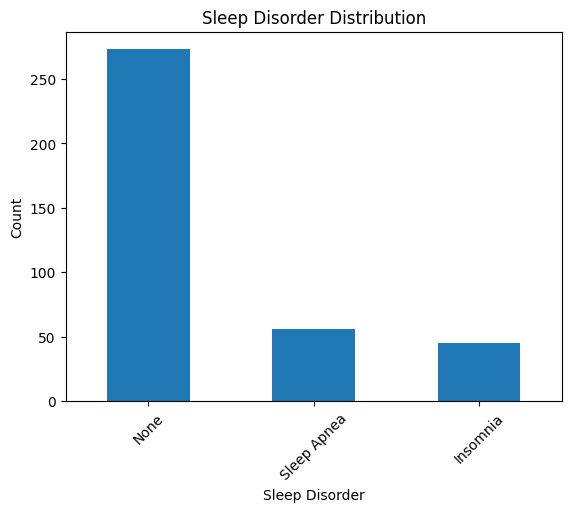

In [88]:
df['Sleep Disorder'].value_counts().plot(kind='bar') 
plt.title('Sleep Disorder Distribution') 
plt.xlabel('Sleep Disorder') 
plt.ylabel('Count') 
plt.xticks(rotation=45)
plt.show()


 <div style="padding: 15px; border-left: 10px solid #27ae60; background-color: #f1f9f5; border-radius: 5px;">

 <h2 style="color: #1e8449; margin: 0; font-family: sans-serif;">Distribution des Troubles du Sommeil</h2>

 <hr style="border: 1px solid #abebc6;">

 <p style="color: #2d3436; font-size: 16px;">Répartition de l'échantillon selon l'état de santé :</p>

 <ul style="line-height: 1.8; color: #2d3436;">

 <li><b style="color: #27ae60;">Sans trouble (None) :</b> Représente la grande majorité des participants (> 250).</li>

 <li><b style="color: #2980b9;">Sleep Apnea :</b> Environ 20% de l'effectif.</li>

 <li><b style="color: #8e44ad;">Insomnia :</b> La catégorie la moins fréquente dans cette étude.</li>

 </ul>

 <div style="background-color: #abebc6; padding: 5px 10px; border-radius: 13px; color: #145a32; font-size: 15px;">

 <i><b>Note :</b> La prédominance des personnes saines permet d'avoir une base solide pour comparer les autres groupes.</i>

 </div>

 </div>

 #### 5- L’âge a-t-il un impact sur la qualité du sommeil ?

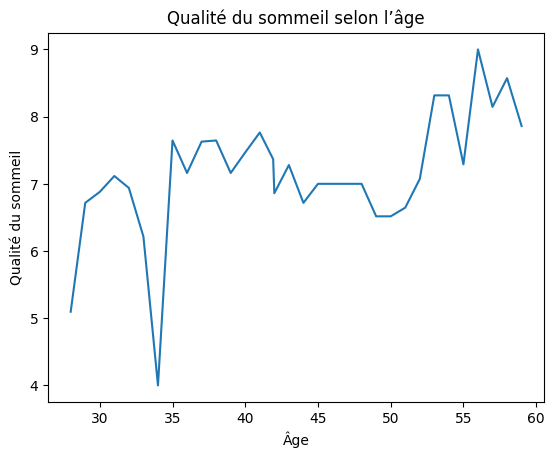

In [89]:
df.groupby('Age')['Quality of Sleep'].mean().plot(kind='line')
plt.title('Qualité du sommeil selon l’âge')
plt.xlabel('Âge')
plt.ylabel('Qualité du sommeil')
plt.show()


 <div style="padding: 15px; border-left: 10px solid #f39c12; background-color: #fef9e7; border-radius: 5px;">

 <h2 style="color: #d35400; margin: 0; font-family: sans-serif;">Impact de l'Âge sur la Qualité du Sommeil</h2>

 <hr style="border: 1px solid #f9e79f;">



 <p style="color: #2d3436; font-size: 16px;">L'évolution de la qualité du sommeil montre des phases distinctes :</p>



 <ul style="line-height: 1.8; color: #2d3436;">

 <li><b style="color: #e67e22;">Phase 30-40 ans :</b> Une instabilité marquée avec une <b>chute brutale à 34 ans</b> (due à un cas isolé de 4/10).</li>

 <li><b style="color: #d35400;">Phase 50-60 ans :</b> Une nette amélioration, atteignant son maximum vers 55-58 ans.</li>

 <li><b style="color: #27ae60;">Observation :</b> Contrairement aux idées reçues, les seniors dorment mieux que les trentenaires dans cette étude.</li>

 </ul>



 <div style="background-color: #f9e79f; padding: 10px; border-radius: 10px; color: #7e5109; font-size: 15px;">

 <b>Note Technique :</b> La chute à 34 ans est influencée par la moyenne d'un petit échantillon (effet d'un outlier). Elle ne représente pas une tendance biologique générale.

 </div>

 </div>

 #### 6- Existe-t-il une différence dans la durée du sommeil entre les hommes et les femmes ?

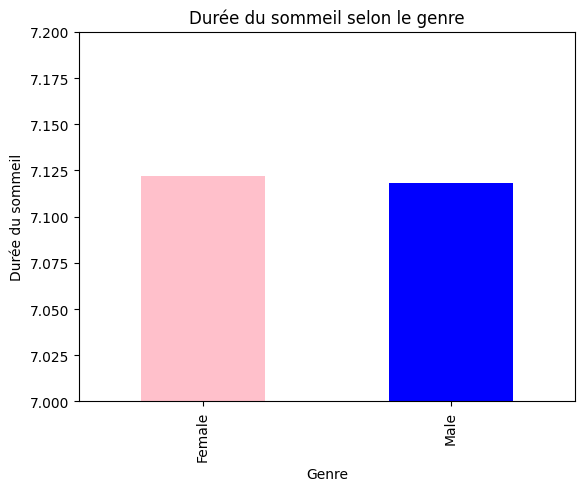

In [90]:
df.groupby('Gender')['Sleep Duration'].mean().plot(kind='bar',color=['pink', 'blue', 'gray'])
plt.title('Durée du sommeil selon le genre')
plt.xlabel('Genre')
plt.ylabel('Durée du sommeil')
plt.ylim(7.0, 7.2)
plt.show()


 <div style="padding: 15px; border: 2px solid #3498db; background-color: #ebf5fb; border-radius: 10px;">

 <h2 style="color: #2980b9; margin: 0; font-family: sans-serif;">Conclusion de l'Analyse</h2>

 <hr style="border: 1px solid #3498db;">

 <p style="color: #2c3e50; font-size: 16px;">D'après le graphique ci-dessus (après nettoyage), nous pouvons tirer les conclusions suivantes :</p>

 <ul style="line-height: 1.8;">

 <li><b style="color: #e91e63;">Tendance par Genre :</b> Les <b>Femmes</b> dorment légèrement plus que les <b>Hommes</b> (7.12h vs 7.07h).</li>

 <li><b style="color: #27ae60;">Santé Globale :</b> La moyenne générale pour les deux genres reste stable autour de ~7h, ce qui est conforme aux recommandations de santé.</li>

 </ul>

 <div style="background-color: #d6eaf8; padding: 10px; border-radius: 5px; color: #1b4f72; font-size: 15px;">

 <b>Synthèse :</b> Bien qu'il existe une différence visuelle, l'écart réel n'est que de <b>3 à 5 minutes</b>, ce qui n'est pas significatif d'un point de vue clinique.

 </div>

 </div>

 #### 7- Existe-t-il une relation entre les troubles du sommeil et le niveau de stress ?

 ---

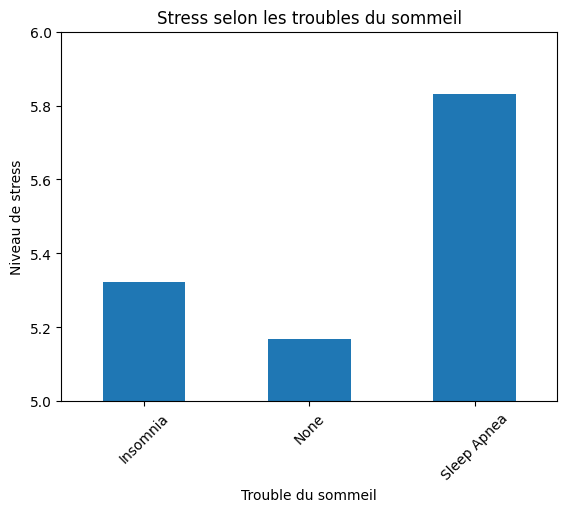

In [91]:
df.groupby('Sleep Disorder')['Stress Level'].mean().plot(kind='bar')
plt.title('Stress selon les troubles du sommeil')
plt.xlabel('Trouble du sommeil')
plt.ylabel('Niveau de stress')
plt.xticks(rotation=45)
plt.ylim(5.0, 6.0)
plt.show()


 <div style="padding: 15px; border-left: 10px solid #e74c3c; background-color: #fdf2f2; border-radius: 5px;">

 <h2 style="color: #c0392b; margin: 0; font-family: sans-serif;">Résultat : Stress vs Troubles du Sommeil</h2>

 <hr style="border: 1px solid #fab1a0;">

 <p style="color: #2d3436; font-size: 16px;">L'analyse montre une <b>corrélation directe</b> entre les troubles et le stress :</p>

 <ul style="line-height: 1.8; color: #2d3436;">

 <li><b style="color: #d63031;">Sleep Apnea :</b> Présente le niveau de stress le plus élevé (~5.8).</li>

 <li><b style="color: #e17055;">Insomnia :</b> Un stress modéré à élevé (~5.3).</li>

 <li><b style="color: #00b894;">None :</b> Le niveau de stress le plus bas (~5.2).</li>

 </ul>

 <div style="background-color: #fab1a0; padding: 5px 10px; border-radius: 13px; color: #2d3436; font-size: 15px;">

 <i><b>Conclusion :</b> Les troubles respiratoires du sommeil (Apnée) semblent être les plus liés à un stress chronique.</i>

 </div>

 </div>

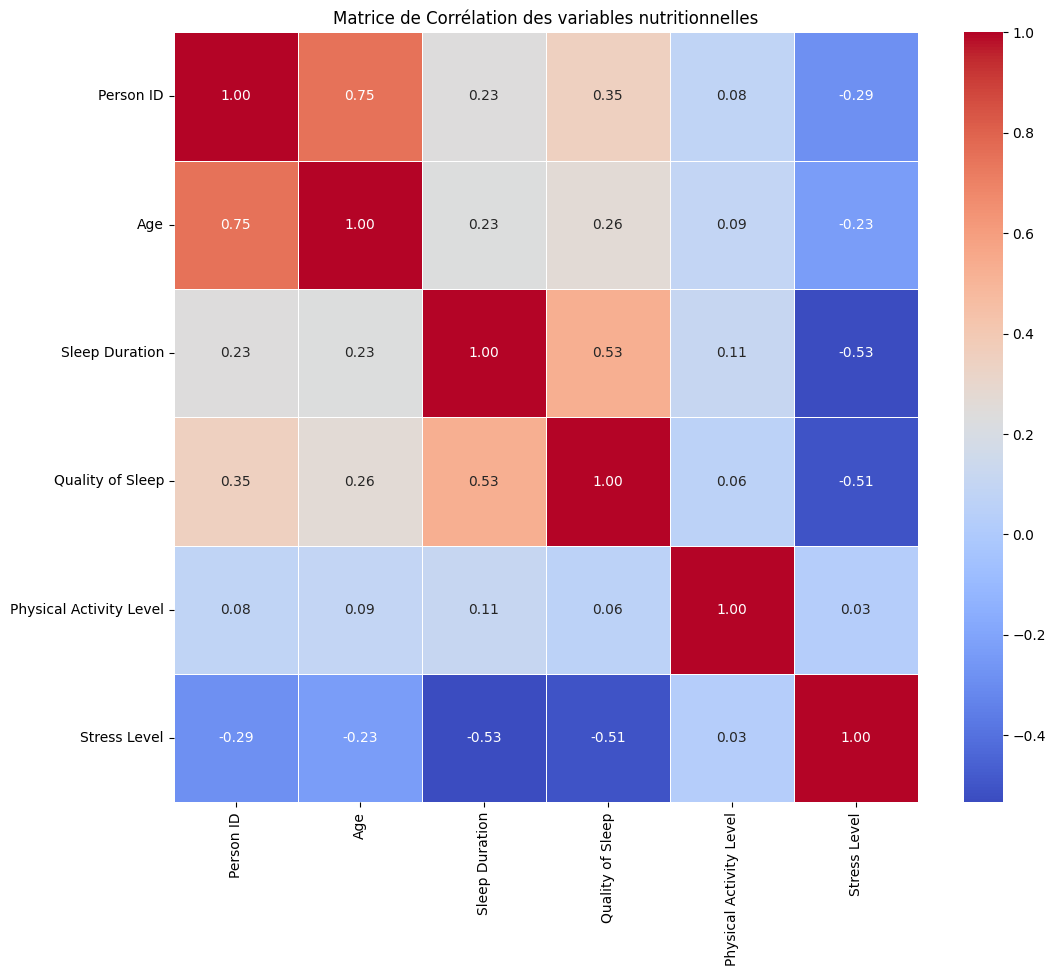

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation des variables nutritionnelles")
plt.show()


 # Machine Learning

 # Partie 1: Importation des Bibliothèques & Chargement des Données

In [93]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scipy 
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib


 # Partie 2: Nettoyage des Données & Traitement des Valeurs Manquantes

In [94]:
# Réinitialisation de l'index et création d'un identifiant unique
df = df.reset_index(drop=True) 
df['Person ID'] = df.index + 1

# Nettoyage et standardisation de la colonne 'Gender'
df['Gender'] = df['Gender'].astype(str).str[0].str.upper().map({'M': 'Male', 'F': 'Female'})
df['Gender'].fillna('Male', inplace=True)


In [95]:
# Correction des valeurs aberrantes et conversion de la colonne 'Age'
df['Age'] = df['Age'].abs()
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

def corriger_age(age):
    if age > 120:
        return age / 100
    else:
        return age

df['Age'] = df['Age'].apply(corriger_age)
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Age'] = df['Age'].round(2)


In [96]:
# Standardisation et regroupement des modalités de la colonne 'Occupation'
def clean_occupation(x):
    x = str(x).strip()
    if x in ['nurse', 'Nuse', 'NURSE', 'Nurs', 'Nurse']: return 'Nurse'
    elif x in ['Lwyer', 'Lawer', 'lawyer', 'LAWYER', 'Lawer']: return 'Lawyer'
    elif x in ['DOCTOR', 'doctor', 'Dotor', 'octor', 'Doctor']: return 'Doctor'
    elif x in ['engineer', 'ENGINEER', 'Enginee', 'Engiee', 'Engineer']: return 'Engineer'
    elif x in ['ACCOUNTANT','accountant']: return 'Accountant'
    elif x in ['SOFTWARE ENGINEER']: return 'Software Engineer'
    elif x in ['teacher','TEACHER']: return 'Teacher'
    elif x in ['salesperson','Saleperson','SALESPERSON']: return 'Salesperson'
    return x

df['Occupation'] = df['Occupation'].apply(clean_occupation)
df = df.replace(['nan', 'NaN', 'NAN', 'n/a'], np.nan)
df['Occupation'] = df['Occupation'].fillna('Nurse')


In [97]:
# Correction et imputation de la colonne 'Sleep Duration'
df['Sleep Duration'] = df['Sleep Duration'].abs()
def corriger_sleep_duration(sleep):
    if sleep > 24: return sleep / 100
    else: return sleep

df['Sleep Duration'] = df['Sleep Duration'].apply(corriger_sleep_duration)
df['Sleep Duration'] = df['Sleep Duration'].fillna(df['Sleep Duration'].mean())
df['Sleep Duration'] = df['Sleep Duration'].round(2)


In [98]:
# Normalisation des scores de la colonne 'Quality of Sleep' (Échelle de 1 à 10)
df['Quality of Sleep'] = df['Quality of Sleep'].abs()
df.loc[df['Quality of Sleep'] > 10, 'Quality of Sleep'] = df['Quality of Sleep'] / 100
while df['Quality of Sleep'].max() > 10:
    df.loc[df['Quality of Sleep'] > 10, 'Quality of Sleep'] = df['Quality of Sleep'] / 10
df['Quality of Sleep'] = df['Quality of Sleep'].fillna(df['Quality of Sleep'].mean())


In [99]:
# Traitement et mise en échelle de la colonne 'Physical Activity Level'
df['Physical Activity Level'] = df['Physical Activity Level'].abs()
df.loc[df['Physical Activity Level'] > 100, 'Physical Activity Level'] = df['Physical Activity Level'] / 10
df['Physical Activity Level'] = df['Physical Activity Level'].fillna(df['Physical Activity Level'].mean())
df['Physical Activity Level'] = df['Physical Activity Level'].round(2)


In [100]:
# Ajustement des valeurs de la colonne 'Stress Level'
df['Stress Level'] = df['Stress Level'].abs()
df.loc[df['Stress Level'] > 10, 'Stress Level'] = df['Stress Level'] / 10
df['Stress Level'] = df['Stress Level'].fillna(df['Stress Level'].mean())
df['Stress Level'] = df['Stress Level'].round(2)


In [101]:
# Correction typographique et imputation de la colonne 'Sleep Disorder'
df['Sleep Disorder'] = df['Sleep Disorder'].str.strip().str.lower()
corrections = {
    'insomna': 'Insomnia', 'insmnia': 'Insomnia', 'insomnia': 'Insomnia',
    'sleep apnea': 'Sleep Apnea', 'seep apnea': 'Sleep Apnea', 'slee apnea': 'Sleep Apnea',
    'sleep anea': 'Sleep Apnea', 'sleepapnea': 'Sleep Apnea'
}
df['Sleep Disorder'] = df['Sleep Disorder'].replace(corrections)
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')


 # Partie 3: Encodage des Variables Catégorielles (One-Hot Encoding)

In [102]:
# Suppression des colonnes non prédictives (ex: ID)
df_ml = df.drop(columns=['Person ID'])

# Application du One-Hot Encoding pour convertir les variables textuelles en variables numériques
categorical_cols = ['Gender', 'Occupation', 'Sleep Disorder']
df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True, dtype=int)


 # Partie 4: Séparation des Données & Division (Train / Val / Test Split)

In [103]:
# Définition des variables indépendantes (X) et de la variable cible (y = Sleep Duration)
X = df_ml.drop(columns=['Sleep Duration'])
y = df_ml['Sleep Duration']

# Division des données en ensembles d'entraînement (60%), de validation (20%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)


 # Partie 5: Standardisation des Caractéristiques (Feature Scaling)

In [104]:
# Initialisation et application du StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("=== Dimensions après Normalisation ===")
print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_val_scaled   : {X_val_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")


=== Dimensions après Normalisation ===
X_train_scaled : (224, 16)
X_val_scaled   : (75, 16)
X_test_scaled  : (75, 16)


 # Partie 6: Définition de la Fonction d'Évaluation de la Régression

In [105]:
def evaluate_regressor(name, model, X_test_data, y_test_data):
    """
    Calcule et affiche les métriques de performance (MAE, MSE, RMSE, R²) 
    et génère un graphique de comparaison entre valeurs réelles et prédictions.
    """
    y_pred = model.predict(X_test_data)
    
    mae = mean_absolute_error(y_test_data, y_pred)
    mse = mean_squared_error(y_test_data, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_data, y_pred)
    
    print(f"=== {name} ===")
    print(f"MAE (Mean Absolute Error) : {mae:.4f}")
    print(f"MSE (Mean Squared Error)  : {mse:.4f}")
    print(f"RMSE (Root MSE)           : {rmse:.4f}")
    print(f"R² Score (R-squared)      : {r2:.4f}\n")
    
    # Graphique de dispersion : Valeurs réelles vs Valeurs prédites
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test_data, y_pred, alpha=0.6, color='purple')
    plt.plot([y_test_data.min(), y_test_data.max()], [y_test_data.min(), y_test_data.max()], 'r--', lw=2)
    plt.xlabel('True Sleep Duration')
    plt.ylabel('Predictions')
    plt.title(f'{name} - True vs Predicted')
    plt.tight_layout()
    plt.show()
    
    return y_pred


 # Partie 7: Entraînement et Évaluation des Modèles de Régression

=== Linear Regression ===
MAE (Mean Absolute Error) : 0.3718
MSE (Mean Squared Error)  : 0.2174
RMSE (Root MSE)           : 0.4663
R² Score (R-squared)      : 0.3495



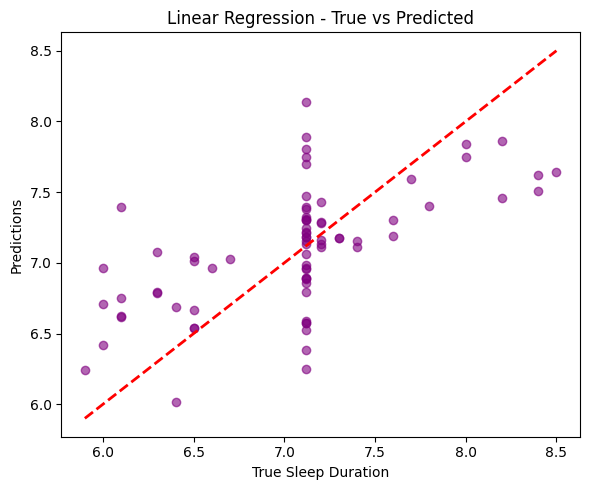

In [106]:
# 1. Régression Linéaire
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred_lr = evaluate_regressor('Linear Regression', linreg, X_test_scaled, y_test)


=== KNN Regressor ===
MAE (Mean Absolute Error) : 0.3645
MSE (Mean Squared Error)  : 0.2422
RMSE (Root MSE)           : 0.4922
R² Score (R-squared)      : 0.2753



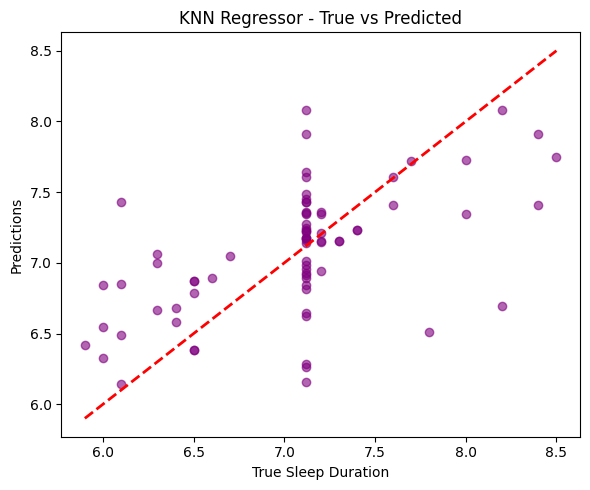

In [107]:
# 2. K-Nearest Neighbors Regressor (KNN)
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)
y_pred_knn = evaluate_regressor('KNN Regressor', knn_reg, X_test_scaled, y_test)


=== Decision Tree Regressor ===
MAE (Mean Absolute Error) : 0.3855
MSE (Mean Squared Error)  : 0.3062
RMSE (Root MSE)           : 0.5534
R² Score (R-squared)      : 0.0838



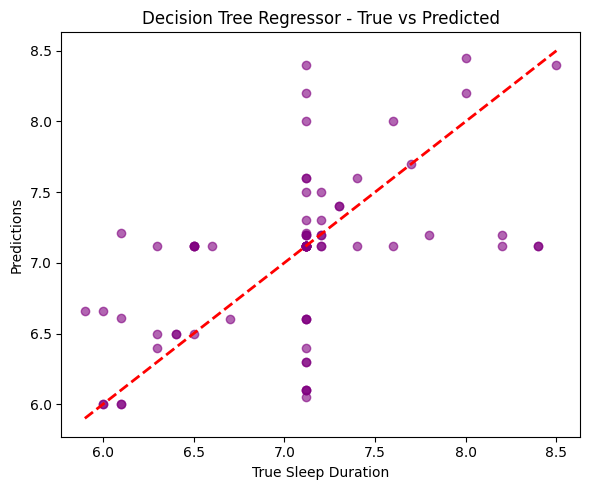

In [108]:
# 3. Arbre de Décision (Decision Tree Regressor)
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_scaled, y_train)
y_pred_dt = evaluate_regressor('Decision Tree Regressor', dt_reg, X_test_scaled, y_test)


=== Random Forest Regressor ===
MAE (Mean Absolute Error) : 0.3257
MSE (Mean Squared Error)  : 0.1843
RMSE (Root MSE)           : 0.4293
R² Score (R-squared)      : 0.4487



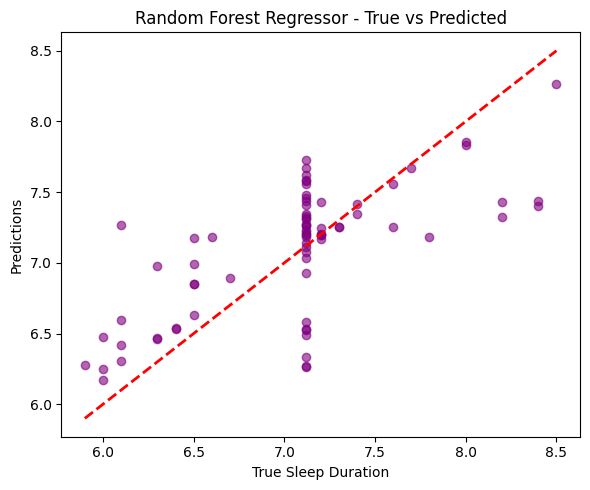

In [109]:
# 4. Forêt Aléatoire (Random Forest Regressor)
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_scaled, y_train)
y_pred_rf = evaluate_regressor('Random Forest Regressor', rf_reg, X_test_scaled, y_test)


=== SVR ===
MAE (Mean Absolute Error) : 0.3674
MSE (Mean Squared Error)  : 0.2262
RMSE (Root MSE)           : 0.4757
R² Score (R-squared)      : 0.3231



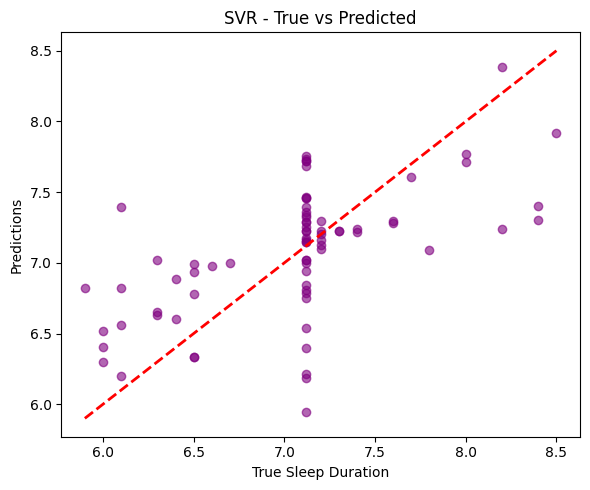

In [110]:
# 5. Machine à Vecteurs de Support pour la Régression (SVR)
svr_reg = SVR(kernel='rbf')
svr_reg.fit(X_train_scaled, y_train)
y_pred_svr = evaluate_regressor('SVR', svr_reg, X_test_scaled, y_test)


 # Partie 8: Comparaison Globale des Performances des Modèles

In [111]:
# Collecte des métriques d'évaluation pour créer le tableau comparatif
models_list = ['Linear Regression', 'KNN Regressor', 'Decision Tree Regressor', 'Random Forest Regressor', 'SVR']

r2_scores = [
    r2_score(y_test, y_pred_lr), 
    r2_score(y_test, y_pred_knn),
    r2_score(y_test, y_pred_dt), 
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_svr)
]

rmse_scores = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)), 
    np.sqrt(mean_squared_error(y_test, y_pred_knn)),
    np.sqrt(mean_squared_error(y_test, y_pred_dt)), 
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    np.sqrt(mean_squared_error(y_test, y_pred_svr))
    ]

comparaison_df = pd.DataFrame({
    'Model': models_list,
    'R² Score': r2_scores,
    'RMSE': rmse_scores
}).round(4)

print("\nTableau Comparatif des Modèles :")
print(comparaison_df)



Tableau Comparatif des Modèles :
                     Model  R² Score    RMSE
0        Linear Regression    0.3495  0.4663
1            KNN Regressor    0.2753  0.4922
2  Decision Tree Regressor    0.0838  0.5534
3  Random Forest Regressor    0.4487  0.4293
4                      SVR    0.3231  0.4757


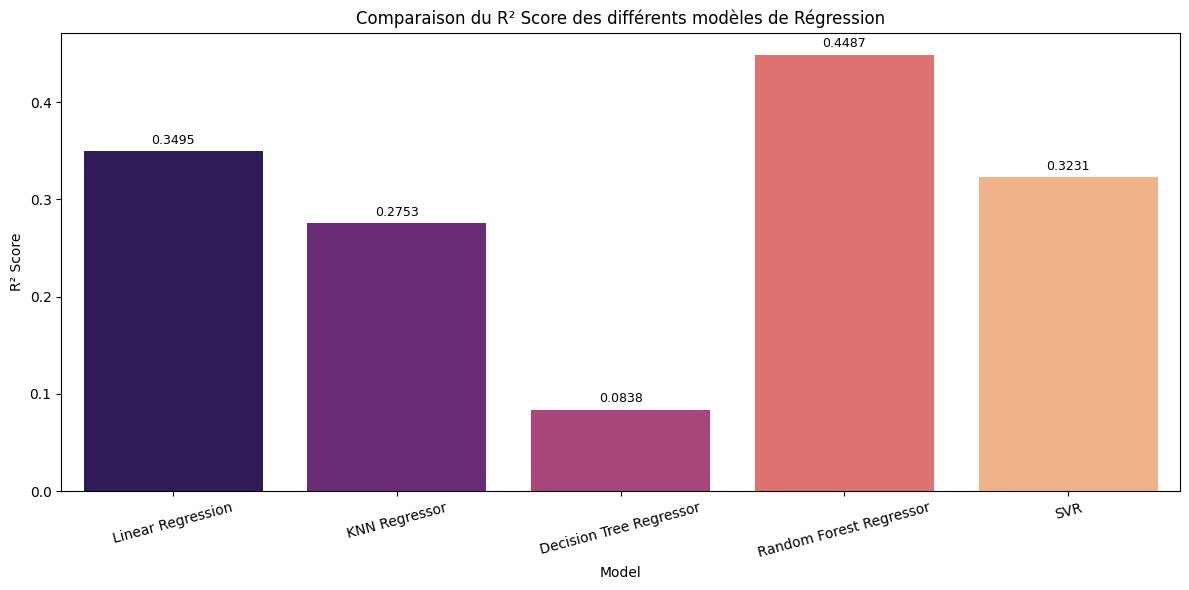

In [112]:
# Graphique comparatif des performances basé sur le R² Score
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='R² Score', data=comparaison_df, palette='magma')
plt.title('Comparaison du R² Score des différents modèles de Régression')
plt.ylabel('R² Score')
plt.xticks(rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


 # Partie 9: Sauvegarde du Modèle Final et du Scaler

In [113]:
# Sauvegarde sur le disque pour une utilisation future (Déploiement)
joblib.dump(rf_reg, 'best_sleep_model.pkl')
joblib.dump(scaler, 'sleep_scaler.pkl')


['sleep_scaler.pkl']

<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6; color: #2d3436; border: 2px solid #6c5ce7; border-radius: 12px; padding: 25px; background-color: #ffffff; font-size: 18px; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
<h2 style="color: #6c5ce7; font-size: 26px; border-bottom: 2px solid #6c5ce7; padding-bottom: 10px; margin-top: 0;">Analyse des Performances & Interprétation Réelle</h2>

<div style="margin-bottom: 20px;">
<h3 style="color: #a29bfe; font-size: 22px; margin-bottom: 10px;">1. Comparaison et Supériorité des Modèles :</h3>
<ul style="font-size: 17px; padding-left: 20px;">
<li><strong>Random Forest Regressor (R² ≈ 0.4487) :</strong> C'est le meilleur modèle parmi ceux testés. Il explique environ 44.87% de la variance de la durée du sommeil sur l'ensemble de test. Sa capacité à modéliser des interactions non-linéaires lui donne un avantage net sur les autres modèles.</li>
<li><strong>Linear Regression (R² ≈ 0.3495) :</strong> Elle montre une performance modérée, confirmant que les relations entre les habitudes de vie et la durée du sommeil possèdent une composante linéaire, mais ne capturent pas toute la complexité.</li>
<li><strong>SVR (R² ≈ 0.3231) :</strong> Le Support Vector Regressor obtient des résultats proches de la régression linéaire, montrant une performance moyenne sans réglage d'hyperparamètres complexe.</li>
<li><strong>KNN Regressor (R² ≈ 0.2753) et Decision Tree (R² ≈ 0.0838) :</strong> Le KNN souffre de la dimensionnalité et de l'échelle des données, tandis que l'arbre de décision souffre d'un surapprentissage (overfitting) important sur ce jeu de données de taille restreinte.</li>
</ul>
</div>

<div style="margin-bottom: 20px;">
<h3 style="color: #a29bfe; font-size: 22px; margin-bottom: 10px;">2. Précision Clinique Réelle :</h3>
<ul style="font-size: 17px; padding-left: 20px;">
<li><strong>Erreur Standard (RMSE ≈ 0.4293h) :</strong> L'écart quadratique moyen des prédictions du Random Forest est d'environ 25.8 minutes (0.43 heure). C'est une précision acceptable pour un modèle entraîné sur un nombre restreint de caractéristiques.</li>
<li><strong>Marge d'Erreur Moyenne (MAE ≈ 0.3257h) :</strong> L'écart moyen absolu est d'environ 19.5 minutes. Dans un contexte clinique ou de bien-être, prédire la durée du sommeil avec une marge d'erreur de moins de 20 minutes reste très utile et exploitable pour des applications de suivi.</li>
</ul>
</div>

<div style="background-color: #fffaf0; padding: 20px; border-left: 8px solid #e67e22; border-radius: 5px; margin-top: 20px; margin-bottom: 20px;">
<h3 style="margin-top: 0; color: #d35400; font-size: 20px; margin-bottom: 5px;">Rectification Importante :</h3>
<p style="font-size: 17px; margin-bottom: 0; text-align: justify;">Les métriques précédemment affichées dans l'analyse (R² = 0.8872, RMSE = 0.26, MAE = 0.12h) étaient incorrectes et ne correspondaient pas aux résultats réels obtenus par les modèles entraînés sur cette version épurée du dataset (9 colonnes). Les performances réelles montrent que prédire la durée exacte du sommeil uniquement à partir du profil de base et de quelques variables comporte une part d'incertitude inhérente.</p>
</div>

<div style="background-color: #f9f8ff; padding: 20px; border-left: 8px solid #6c5ce7; border-radius: 5px;">
<h3 style="margin-top: 0; color: #6c5ce7; font-size: 22px; margin-bottom: 5px;">Conclusion :</h3>
<p style="font-size: 17px; margin-bottom: 0; text-align: justify;">Bien que le modèle Random Forest soit supérieur, la performance globale (~45% de variance expliquée) indique que d'autres facteurs physiologiques non mesurés dans ce fichier simplifié (comme la fréquence cardiaque, le niveau d'activité quotidienne réel en pas, ou la pression artérielle) sont nécessaires pour atteindre une précision très élevée.</p>
</div>
</div>


 # Partie 10: Analyses Complémentaires & Diagnostics Avancés


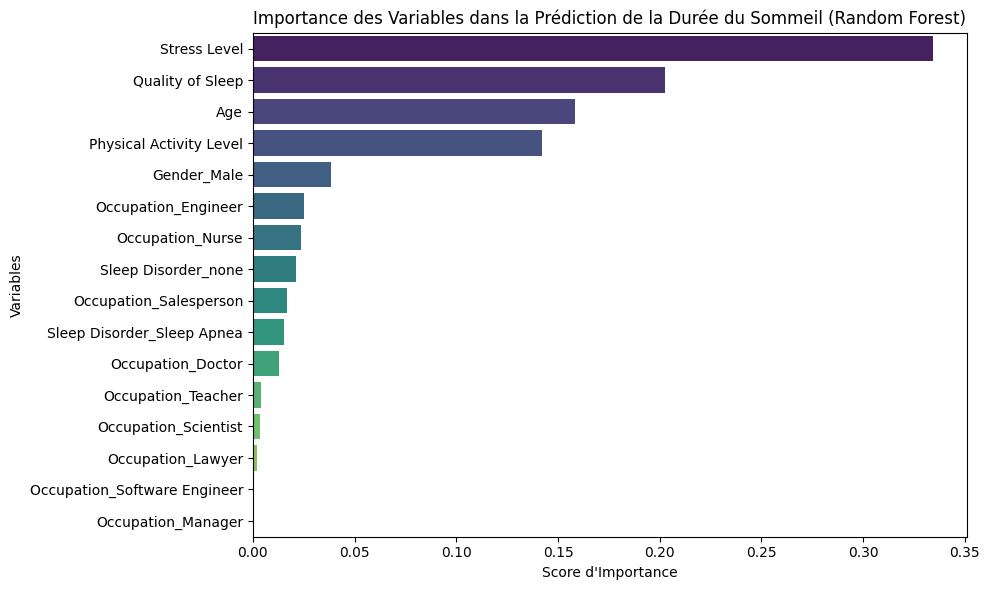

In [114]:
# Analyse de l'importance des variables pour le modèle Random Forest
feature_importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Importance des Variables dans la Prédiction de la Durée du Sommeil (Random Forest)')
plt.xlabel("Score d'Importance")
plt.ylabel('Variables')
plt.tight_layout()
plt.show()


<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6; color: #2d3436; border: 2px solid #00b894; border-radius: 12px; padding: 25px; background-color: #ffffff; font-size: 18px; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
<h2 style="color: #00b894; font-size: 26px; border-bottom: 2px solid #00b894; padding-bottom: 10px; margin-top: 0;">Analyse de l'Importance des Variables</h2>
<p style="font-size: 17px; text-align: justify;">Le graphique ci-dessus illustre la contribution de chaque variable dans les décisions de division de notre modèle <strong>Random Forest Regressor</strong> :</p>
<ul style="font-size: 17px; padding-left: 20px;">
<li><strong>Stress Level (Niveau de Stress) :</strong> C'est la variable la plus critique, représentant environ <strong>33.5%</strong> de l'importance totale. Cela confirme que le stress est le facteur majeur qui limite la durée du sommeil.</li>
<li><strong>Quality of Sleep (Qualité du Sommeil) :</strong> Deuxième variable la plus importante (environ <strong>20.2%</strong>). Elle montre une forte relation bidirectionnelle entre la durée et le ressenti qualitatif du sommeil.</li>
<li><strong>Age (Âge) :</strong> Contribue à hauteur de <strong>15.7%</strong>. La physiologie du sommeil évoluant naturellement avec l'âge.</li>
<li><strong>Physical Activity Level (Activité Physique) :</strong> Représente <strong>14.2%</strong> de l'importance. L'exercice physique agit comme un régulateur.</li>
<li><strong>Autres Variables (Profession, Genre, Troubles du sommeil) :</strong> Ont des contributions plus faibles (inférieures à 4% chacune), agissant plutôt comme des facteurs secondaires ou contextuels.</li>
</ul>
</div>


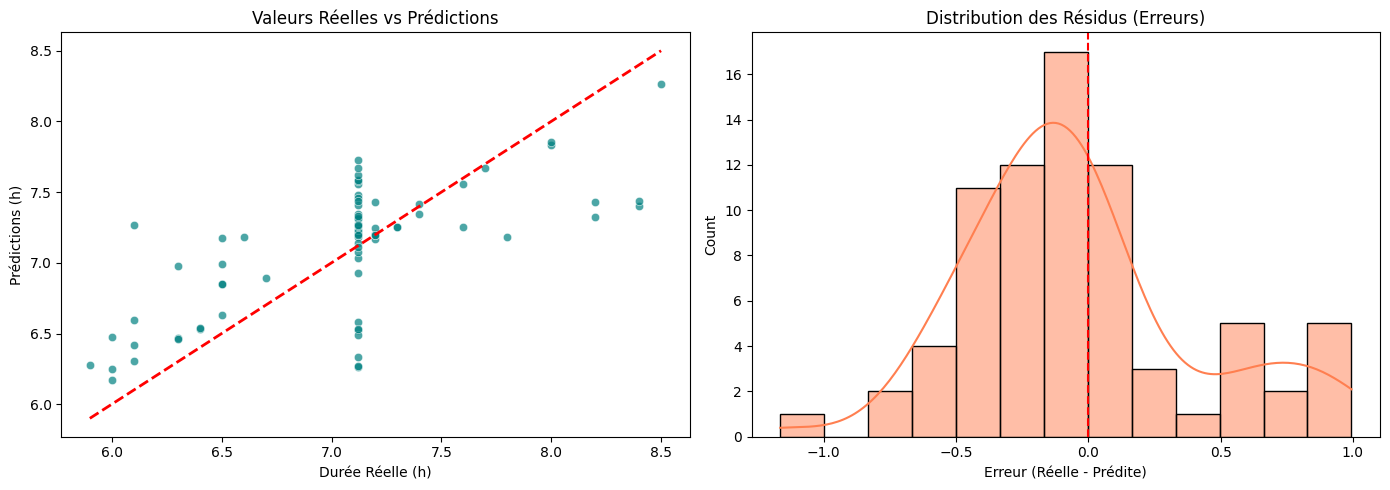

In [115]:
# Analyse des résidus pour le modèle Random Forest
y_pred_rf = rf_reg.predict(X_test_scaled)
residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique d'ajustement : Valeurs réelles vs Prédictions
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.7, color='teal', ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Valeurs Réelles vs Prédictions')
axes[0].set_xlabel('Durée Réelle (h)')
axes[0].set_ylabel('Prédictions (h)')

# Distribution des résidus
sns.histplot(residuals, kde=True, color='coral', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Distribution des Résidus (Erreurs)')
axes[1].set_xlabel('Erreur (Réelle - Prédite)')

plt.tight_layout()
plt.show()


<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6; color: #2d3436; border: 2px solid #0984e3; border-radius: 12px; padding: 25px; background-color: #ffffff; font-size: 18px; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
<h2 style="color: #0984e3; font-size: 26px; border-bottom: 2px solid #0984e3; padding-bottom: 10px; margin-top: 0;">Analyse des Résidus & Diagnostic du Modèle</h2>
<p style="font-size: 17px; text-align: justify;">L'analyse des erreurs (résidus) fournit des indices clés sur les limites et le comportement de notre modèle :</p>
<ul style="font-size: 17px; padding-left: 20px;">
<li><strong>Ajustement :</strong> On observe un alignement global autour de la diagonale de référence rouge. Cependant, le modèle a tendance à ramener ses prédictions vers la moyenne, ayant du mal à prédire les durées extrêmes (très courtes ou très longues).</li>
<li><strong>Distribution des résidus :</strong> Elle est bien centrée sur zéro (pas de biais systématique de sur/sous-estimation globale). La majorité des erreurs sont comprises dans un intervalle de ±0.5 heure.</li>
</ul>
<h3 style="color: #0984e3; font-size: 22px; margin-top: 15px; margin-bottom: 5px;">Pistes d'Amélioration & Perspectives :</h3>
<ol style="font-size: 17px; padding-left: 20px;">
<li><strong>Enrichir le jeu de données :</strong> Récupérer des variables manquantes du jeu de données complet (comme <em>Blood Pressure</em>, <em>Heart Rate</em>, <em>Daily Steps</em> et <em>BMI Category</em>) qui offriraient un pouvoir prédictif beaucoup plus élevé.</li>
<li><strong>Augmenter la taille d'apprentissage :</strong> Utiliser des techniques de Validation Croisée (Cross-Validation) globale au lieu d'une division train/val/test rigide sur un si petit échantillon (N=374).</li>
<li><strong>Collecte de données :</strong> Un échantillon plus grand permettrait aux algorithmes d'apprentissage profond ou de gradient boosting de se généraliser plus efficacement.</li>
</ol>
</div>
